Resize: (140, 200, 3)


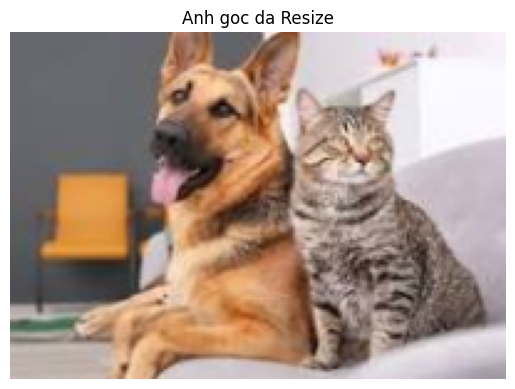


Xu ly anh mau voi K= 5


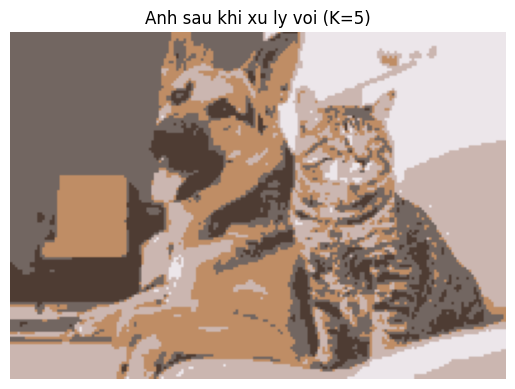


Xu ly anh mau voi K= 10


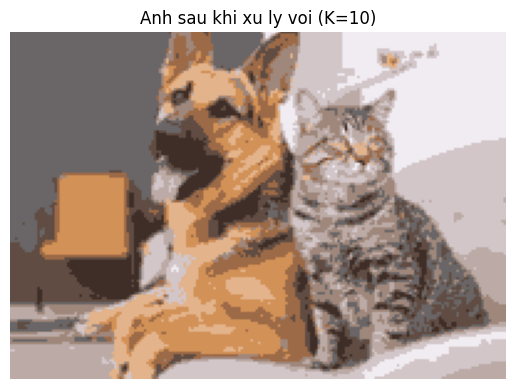


Xu ly anh mau voi K= 15


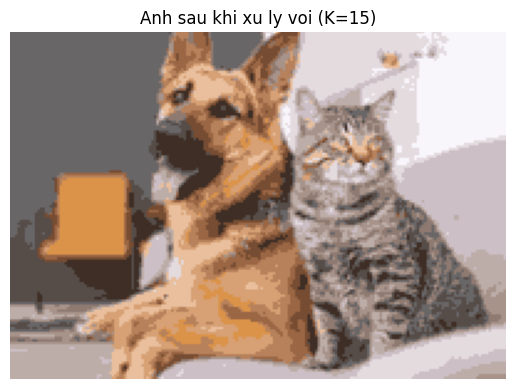


Xu ly anh mau voi K= 20


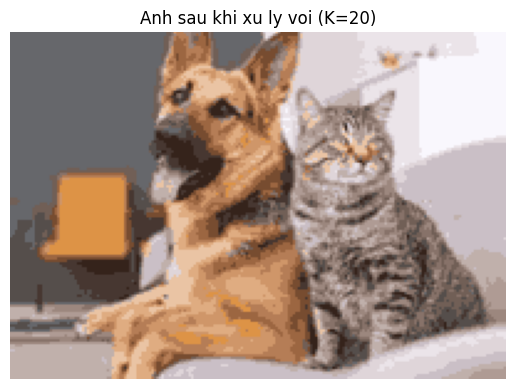

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

#Duong dan data anh va output
INPUT_IMAGE_PATH = 'data/dog_cat.jpg'
OUTPUT_DIR = 'output_color'

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

#Doc file anh
img = cv2.imread(INPUT_IMAGE_PATH)
if img is None:
    print(f"NOTE: Khong tim thay anh '{INPUT_IMAGE_PATH}'.")
    exit()

#BGR -> RGB
#cv2 su dung RGB, plt su dung RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_rgb = cv2.resize(img_rgb, (200, 140))
print(f"Resize: {img_rgb.shape}")

# Hien Thi anh goc
plt.imshow(img_rgb)
plt.title('Anh goc da Resize')
plt.axis('off')
plt.show()

# Luu lai anh goc
color_original_path = os.path.join(OUTPUT_DIR, 'original_color.png')
plt.imsave(color_original_path, img_rgb)

#Xu ly du lieu cho K-means
X_color = img_rgb.reshape(-1, 3)
original_color_size = img_rgb.nbytes

#Chay K-means voi K = {5, 10, 15, 20}
for K in [5, 10, 15, 20]:
    print(f"\nXu ly anh mau voi K= {K}")

    kmeans = KMeans(n_clusters=K, random_state=0, n_init=10).fit(X_color)
    label = kmeans.labels_
    centers = kmeans.cluster_centers_

    #Tai tao anh mau
    img_reconstructed = centers[label].reshape(img_rgb.shape).astype(np.uint8)

    # Hien thi ket qua
    plt.imshow(img_reconstructed)
    plt.title(f'Anh sau khi xu ly voi (K={K})')
    plt.axis('off')
    plt.show()

    # Luu lai anh ket qua
    output_color = os.path.join(OUTPUT_DIR, f'color_K{K}.png')
    plt.imsave(output_color, img_reconstructed)

Anh sau khi xu ly: output_gray
Resize anh: (140, 200)


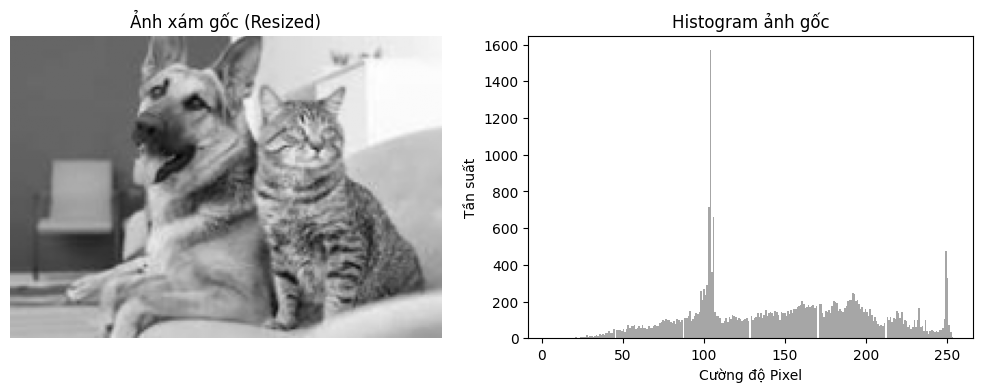


 Xu ly anh xam voi K = 5


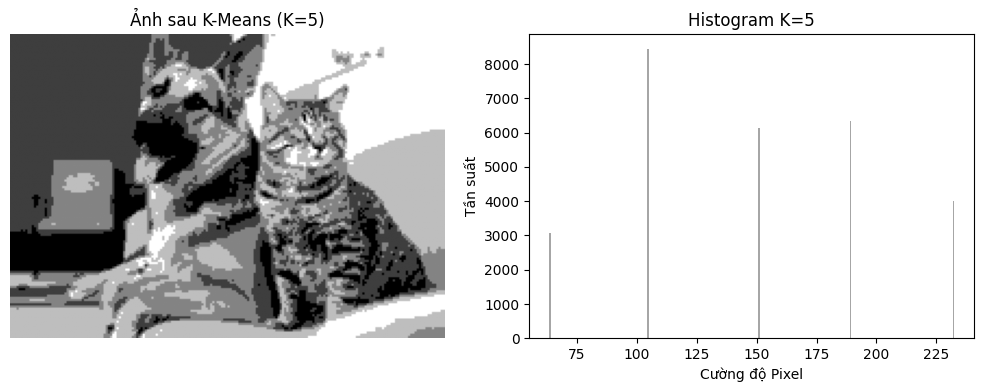


 Xu ly anh xam voi K = 10


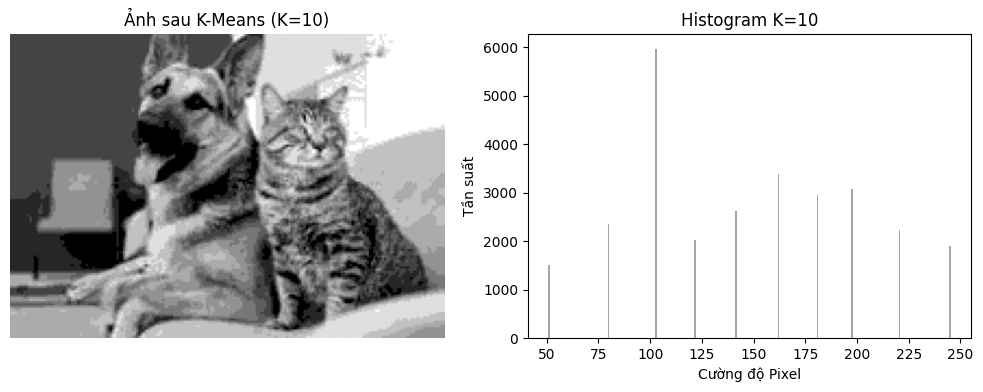


 Xu ly anh xam voi K = 15


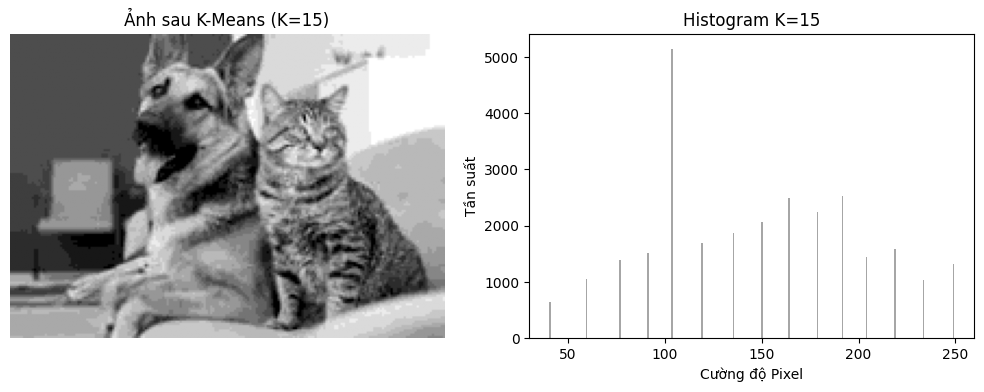


 Xu ly anh xam voi K = 20


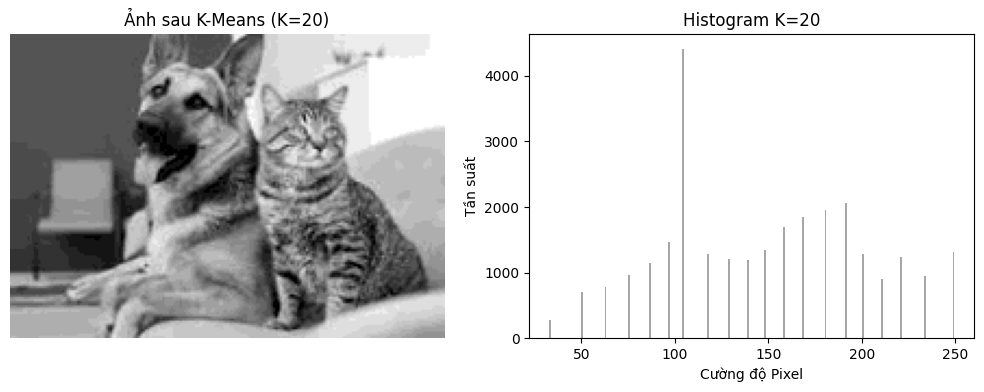

In [2]:
OUTPUT_DIR = 'output_gray'

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
print(f"Anh sau khi xu ly: {OUTPUT_DIR}")

# Chuyen RGB -> anh xam
gray_img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
gray_img = cv2.resize(gray_img, (200, 140))
print(f"Resize anh: {gray_img.shape}")

# Hiển thị ảnh gốc và histogram
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray_img, cmap='gray')
plt.title('Ảnh xám gốc (Resized)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(gray_img.ravel(), bins=256, color='gray', alpha=0.7)
plt.title('Histogram ảnh gốc')
plt.xlabel('Cường độ Pixel')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()

# Luu anh xam goc
gray_original_path = os.path.join(OUTPUT_DIR, 'original_gray.png')
plt.imsave(gray_original_path, gray_img, cmap='gray')

# Du lieu cho K-means
X_gray = gray_img.reshape(-1, 1)
original_gray_size = gray_img.nbytes

# Chay K-means voi k = {5,10,15,20}
for K in [5, 10, 15, 20]:
    print(f"\n Xu ly anh xam voi K = {K}")

    kmeans = KMeans(n_clusters=K, random_state=0, n_init=10).fit(X_gray)
    label = kmeans.labels_
    centers = kmeans.cluster_centers_

    # Tái tạo ảnh
    img_reconstructed = centers[label].reshape(gray_img.shape)

    # Hiển thị ảnh và histogram
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_reconstructed, cmap='gray')
    plt.title(f'Ảnh sau K-Means (K={K})')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.hist(img_reconstructed.ravel(), bins=256, color='gray', alpha=0.7)
    plt.title(f'Histogram K={K}')
    plt.xlabel('Cường độ Pixel')
    plt.ylabel('Tần suất')
    plt.tight_layout()
    plt.show()

    # Lưu ảnh kết quả
    output_gray = os.path.join(OUTPUT_DIR, f'gray_K{K}.png')
    plt.imsave(output_gray, img_reconstructed, cmap='gray')

Phân cụm phân cấp tìm K cụm tối ưu

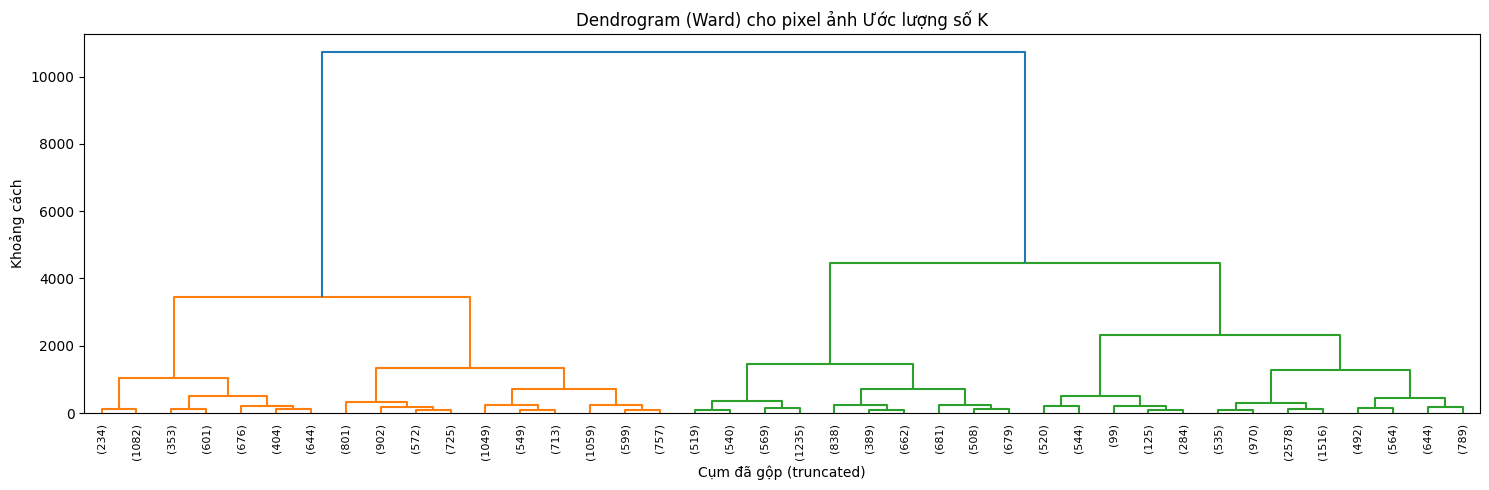

In [ ]:
#Phân cụm phân cấp (HAC) và vẽ biểu đồ Dendrogram (biểu đồ cây)

import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

# Linkage + dendrogram
Z = linkage(X_gray, method="ward")
plt.figure(figsize=(15,5))
#vẽ biểu đồ cây dự trên ma trận z 
dendrogram(Z, truncate_mode="lastp", p=40, leaf_rotation=90)
plt.title("Dendrogram (Ward) cho pixel ảnh Ước lượng số K")
plt.xlabel("Cụm đã gộp (truncated)")
plt.ylabel("Khoảng cách")
plt.tight_layout()
plt.show()